In [29]:
#Import the dataset
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\loren\Desktop\Winedataset.csv"
df = pd.read_csv(file_path)

In [23]:
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

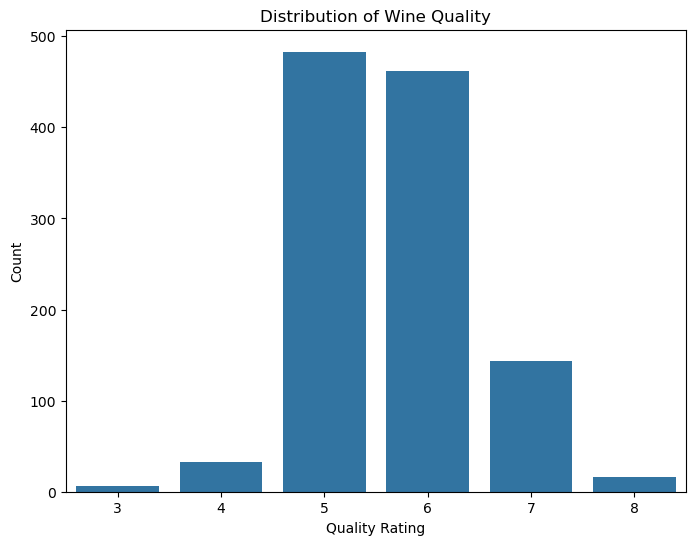

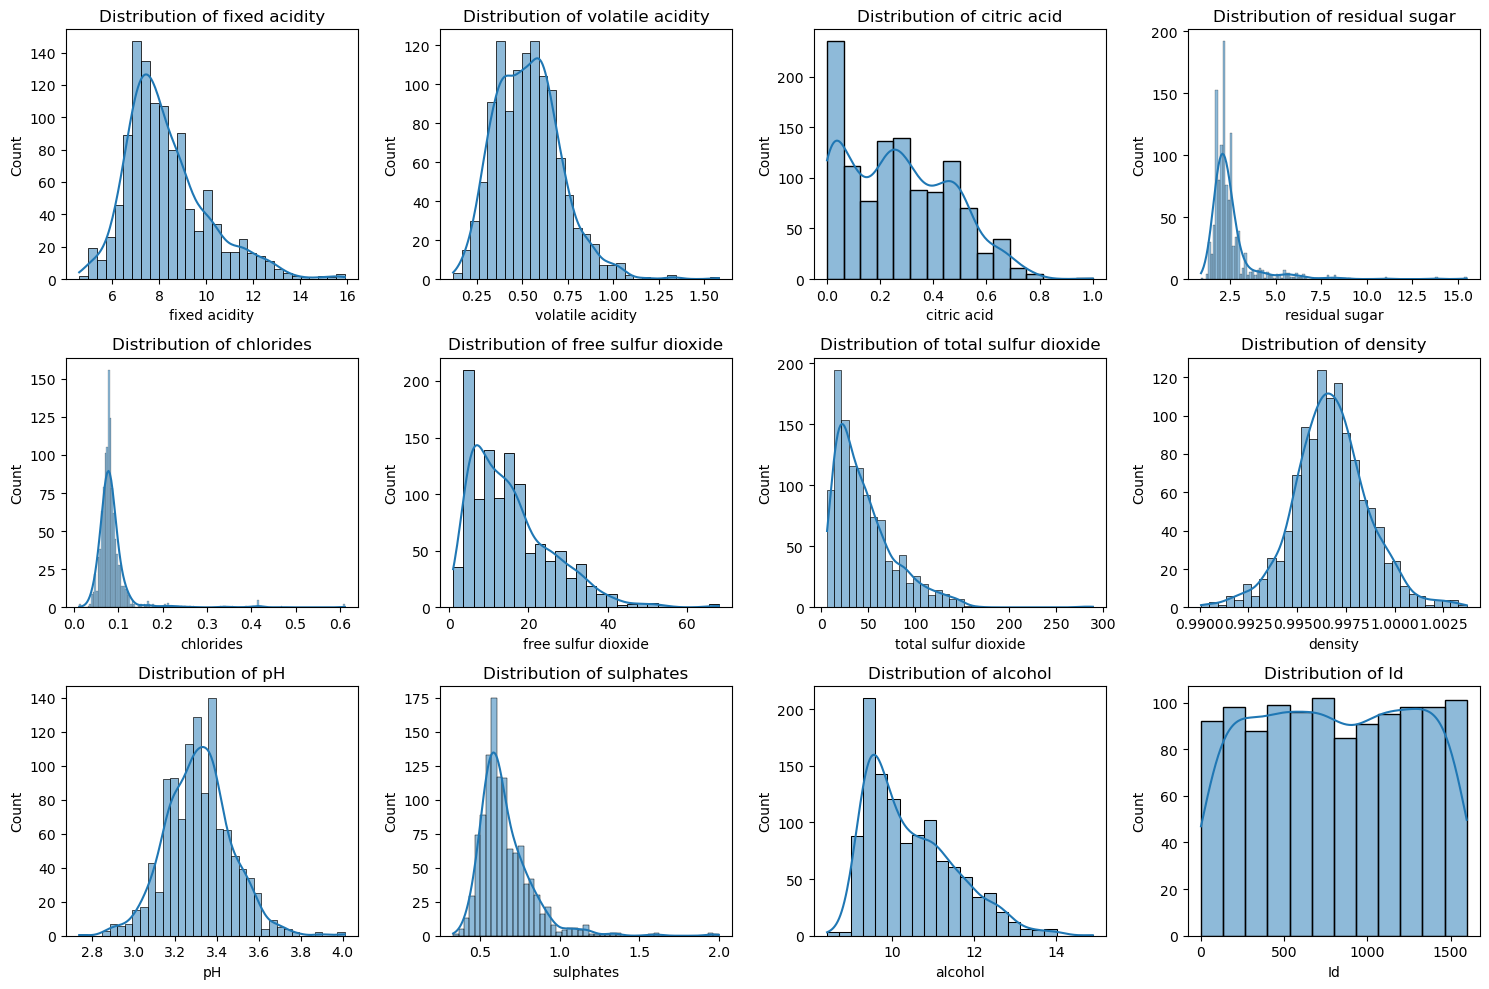

In [30]:
# 1. Distribution of the target variable (quality)
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.show()

# 2. Distribution of numerical features
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
numerical_features.remove('quality') # Remove target variable from numerical features

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 4, i)  # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout() #prevents overlap of subplots
plt.show()

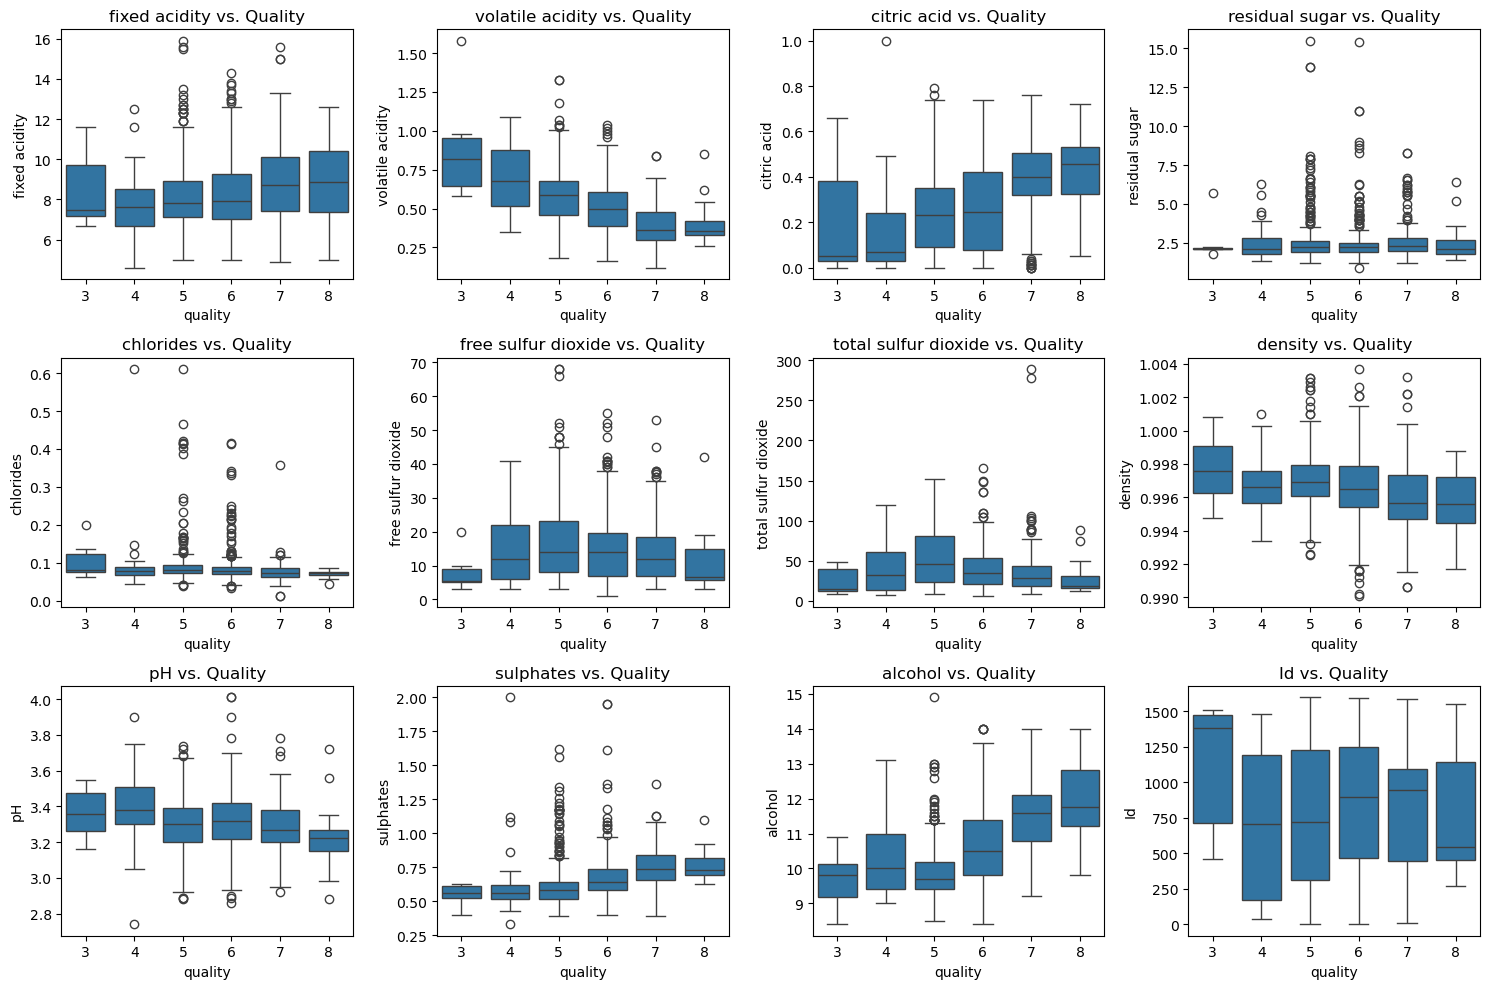

In [33]:
# 3. Box plots for numerical features vs. quality
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x='quality', y=feature, data=df)
    plt.title(f'{feature} vs. Quality')
plt.tight_layout()
plt.show()

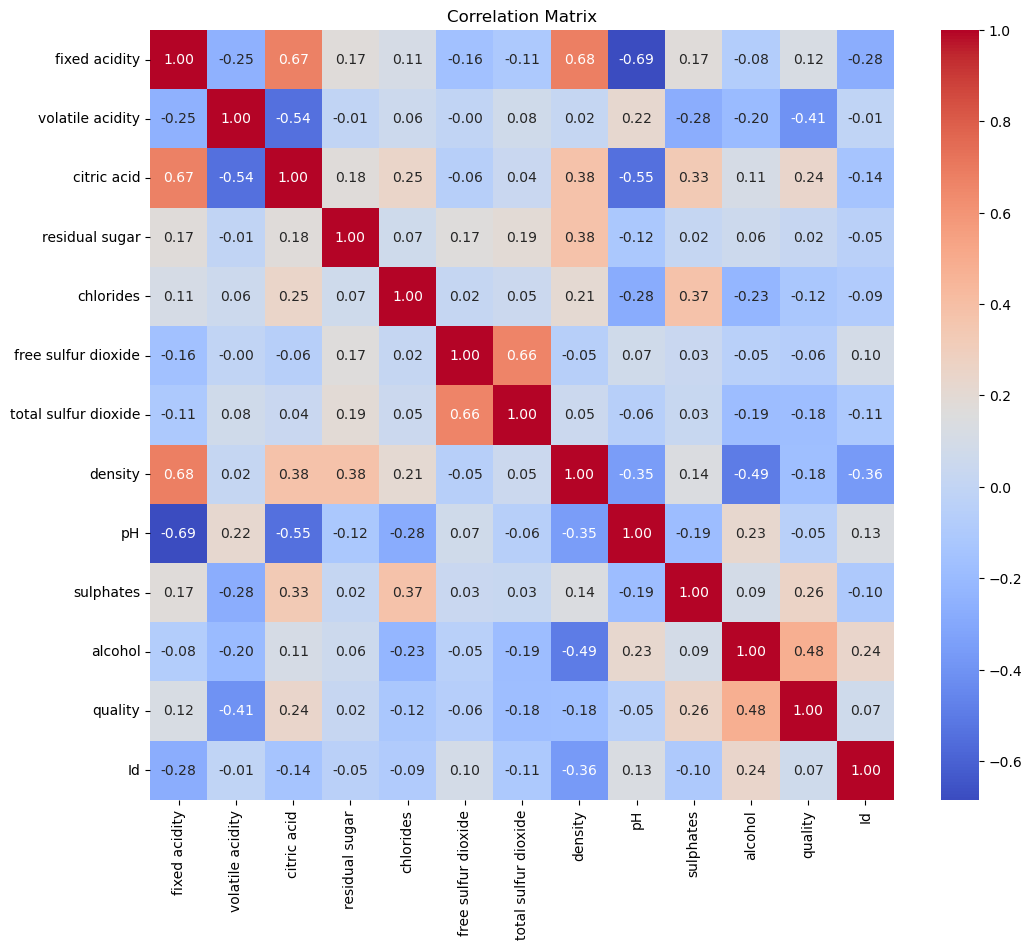

In [35]:
# 4. Correlation matrix (heatmap)
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset (replace with your file path)
try:
    df = pd.read_csv(r"C:\Users\loren\Desktop\Winedataset\data.csv")
except FileNotFoundError:
    print("File not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"An error occurred: {e}")
    exit()

# 2. Prepare the data
X = df.drop('quality', axis=1)  # Features
y = df['quality']  # Target variable

# 3. Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) #stratify maintains class ratios
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Train a Random Forest Classifier (with hyperparameter tuning)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1) #n_jobs=-1 uses all cores, verbose shows progress.
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_

# 6. Evaluate the model on the validation set
y_val_pred = best_rf.predict(X_val_scaled)
print("Validation Set Evaluation:")
print(classification_report(y_val, y_val_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

# 7. Evaluate the model on the test set
y_test_pred = best_rf.predict(X_test_scaled)
print("\nTest Set Evaluation:")
print(classification_report(y_test, y_test_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# 8. Print the best hyperparameters
print("\nBest Hyperparameters:", grid_search.best_params_)

File not found. Please check the file path.
Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\loren\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Validation Set Evaluation:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.74      0.88      0.80        72
           6       0.71      0.70      0.70        69
           7       0.71      0.57      0.63        21
           8       1.00      0.33      0.50         3

    accuracy                           0.73       171
   macro avg       0.53      0.41      0.44       171
weighted avg       0.70      0.73      0.71       171

Validation Accuracy: 0.7251461988304093

Test Set Evaluation:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.77      0.70        73
           6       0.60      0.62      0.61        69
           7       0.50      0.32      0.39        22
           8       0.00      0.00      0.00

C:\Users\loren\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\loren\anaconda3\Lib\site-packag

In [ ]:
The provided results from the wine quality prediction model reveal a scenario characterized by moderate overall accuracy, 
yet significantly hampered by class imbalance and a degree of overfitting. The validation set, exhibiting an accuracy of approximately 73%, 
suggests a reasonable capability to predict wine quality, particularly for the more prevalent quality ratings of 5 and 6. However, 
a deeper dive into the precision, recall, and F1-score metrics exposes the model’s struggle with minority classes (3, 4, 7, and 8). 
The near-zero scores for these classes indicate a severe lack of predictive power, directly attributable to their limited representation within 
the dataset.

The transition from validation to test set performance further underscores these issues. The test accuracy, dropping to around 62%,
points to a tendency of the model to overfit to the training data. This discrepancy suggests that while the model has learned patterns specific 
to the training set, it fails to generalize effectively to unseen data. This is further supported by the significant drop in the macro average of 
the precision, recall and F1-score.

The identified best hyperparameters, while yielding the optimal results within the given search space, do not mitigate the fundamental problem 
of class imbalance. The Random Forest model, despite its robustness, is inherently biased towards the majority classes, leading to poor predictive 
performance for the less frequent quality ratings.

Addressing this imbalance is paramount. Techniques such as SMOTE for oversampling or undersampling strategies could be employed to create a more
balanced training dataset. Furthermore, exploring class weighting within the model itself can help mitigate this bias. Additional strategies include
feature engineering to extract more informative features, experimenting with alternative classification algorithms, and, if feasible, expanding the
dataset with more samples from the underrepresented classes. Finally, reducing model complexity by adjusting hyperparameters like max_depth could
also reduce overfitting. In essence, while the model demonstrates a foundational capability, significant refinements are necessary to improve its
generalization and ensure equitable predictive performance across all quality ratings.